In [2]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import hdbscan
import plotly.express as px
import plotly.graph_objects as go
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from scipy.stats import pearsonr
import statsmodels.api as sm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import dotenv
from openai import OpenAI

In [3]:
df = pd.read_parquet("../datasets/cleaned_datasets/demographic_infused_philly_c.parquet")
df['date'] = pd.to_datetime(df['date'])
print(df.head())
print("Columns:", df.columns)

                review_id                 user_id             business_id  \
0  J1LZjzbs5bFubvS135SD2g  5TE19zTjTIPq1HANACN7sw  dChRGpit9fM_kZK5pafNyA   
1  ecMiAOFucDM3zwXYfY-Q6A  5Z8S9OsHWCnE8wbxk1poQQ  s3Q1J4XEVOBiZy9dYUpqpg   
2  yuFQRhHo3z4TgE6drPXSgg  hcw7ndQKWGEH4P7BYAlG9w  JUlsvVAvZvGHWFfkKm0nlg   
3  Zdh0_HtE724MnohLOrB5Iw  OYaEBYLBrLY4mla8bOMbnA  9b0Mrvs6uJu2jJqet_Jwew   
4  y_XYEZk2Cin-q4N0czeaYw  _9VhEn9zaB-6txE3STNfLw  PYUI1OJVksGUbCrteU68bw   

   stars_rev                                               text  \
0          5  Had a great big meal with family and we loved ...   
1          5  Many locations.  All have lines so be prepared...   
2          5  Compliments to the chef and to the rest of the...   
3          4  I decided to try this spot out -- and it didn'...   
4          3  First off, finding parking is atrocious. Your ...   

                 date               name              address          city  \
0 2020-01-20 00:36:44           The Love        130 S 1

# Sentiment Analysis

In [4]:
nltk.download('vader_lexicon', quiet=True)

def get_vader(text):
    return SentimentIntensityAnalyzer().polarity_scores(text)['compound']

def get_subjectivity(text):
    return TextBlob(text).sentiment.subjectivity

df['sentiment_score'] = df['clean_text'].apply(get_vader)
df['subjectivity_score'] = df['clean_text'].apply(get_subjectivity)

print(df[['clean_text', 'sentiment_score', 'subjectivity_score']].head())

correlation_sent, p_value_sent = pearsonr(df['sentiment_score'], df['stars_rev'])
print(f"Sentiment-Star Correlation: {correlation_sent:.3f}, p-value: {p_value_sent:.5f}")

correlation_subj, p_value_subj = pearsonr(df['subjectivity_score'], df['stars_rev'])
print(f"Subjectivity-Star Correlation: {correlation_subj:.3f}, p-value: {p_value_subj:.5f}")

                                          clean_text  sentiment_score  \
0  great big meal family loved got lot appetizer ...           0.9274   
1  many location line prepared wait well worth fo...           0.9633   
2  compliment chef rest staff hosting lab complai...           0.8834   
3  decided try spot didnt disappoint starter prob...           0.9848   
4  first finding parking atrocious best bet uberl...           0.9630   

   subjectivity_score  
0            0.558333  
1            0.535714  
2            0.535714  
3            0.572222  
4            0.608134  
Sentiment-Star Correlation: 0.657, p-value: 0.00000
Subjectivity-Star Correlation: 0.225, p-value: 0.00000


# Topic Modeling

In [5]:
reviews = df['clean_text'].dropna().tolist()
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.95, min_df=10)
tfidf_matrix = vectorizer.fit_transform(reviews)

n_topics = 10
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
lda.fit(tfidf_matrix)

def get_top_words(model, feature_names, n_top_words=10):
    topics = {}
    for topic_idx, topic in enumerate(model.components_):
        topics[topic_idx] = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
    return topics

feature_names = vectorizer.get_feature_names_out()
topics_words = get_top_words(lda, feature_names)
print("Topics keywords:", topics_words)

topic_assignments = lda.transform(tfidf_matrix)
df['predicted_topic'] = np.argmax(topic_assignments, axis=1)

dotenv.load_dotenv(".env", override=True)
api_key = os.environ.get("OPENAI_API_KEY")
if not api_key:
    raise ValueError("The OPENAI_API_KEY environment variable is not set.")
client = OpenAI(api_key=api_key)

def label_topic(keywords):
    prompt = (
        "Below are some keywords representing a topic extracted from Yelp reviews in Philadelphia, "
        "reflecting urban socio-economic trends:\n\n" +
        f"{', '.join(keywords)}\n\n" +
        "Please provide a concise, evaluable label for this topic (for example, 'Affordable Dining' or 'Luxury Services') "
        "that captures the essence of consumer sentiment and business performance."
    )
    completion = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "developer", "content": "You are a helpful assistant for generating topic labels."},
            {"role": "user", "content": prompt}
        ],
        temperature=0
    )
    label = completion.choices[0].message.content
    return label

topic_labels = {}
for topic_idx, words in topics_words.items():
    topic_labels[topic_idx] = label_topic(words)
print("Topic Labels:", topic_labels)

df['topic_label'] = df['predicted_topic'].map(topic_labels)


Topics keywords: {0: ['taco', 'food', 'good', 'chicken', 'delicious', 'place', 'thai', 'great', 'pho', 'ordered'], 1: ['wedding', 'service', 'day', 'customer', 'card', 'time', 'email', 'package', 'flower', 'order'], 2: ['pizza', 'cheesesteak', 'sandwich', 'good', 'place', 'cheese', 'philly', 'best', 'great', 'food'], 3: ['order', 'food', 'time', 'ordered', 'service', 'dont', 'minute', 'place', 'customer', 'delivery'], 4: ['place', 'time', 'people', 'table', 'room', 'like', 'food', 'store', 'staff', 'drink'], 5: ['good', 'delicious', 'great', 'food', 'got', 'cheese', 'place', 'coffee', 'sandwich', 'ordered'], 6: ['food', 'good', 'great', 'place', 'sushi', 'delicious', 'restaurant', 'service', 'roll', 'menu'], 7: ['car', 'work', 'time', 'service', 'job', 'recommend', 'company', 'day', 'professional', 'great'], 8: ['great', 'food', 'service', 'drink', 'amazing', 'place', 'beer', 'staff', 'atmosphere', 'friendly'], 9: ['nail', 'hair', 'salon', 'time', 'appointment', 'massage', 'great', 'cu

# Geospatial Clustering of Businesses


c:\Users\alche\OneDrive\Documents\GitHub\AllenCheung0213.github.io\CS554_NLP_Final_Project\newenv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\alche\OneDrive\Documents\GitHub\AllenCheung0213.github.io\CS554_NLP_Final_Project\newenv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Cluster-Level Metrics:
      hdbscan_cluster  avg_sentiment  avg_subjectivity  avg_stars  \
0                   0       0.897046          0.618593   4.923077   
1                   1      -0.497300          0.509388   1.363636   
2                   2       0.634766          0.525947   4.008621   
3                   3       0.682583          0.596499   3.750000   
4                   4       0.636400          0.519058   4.310345   
...               ...            ...               ...        ...   
2901             2901       0.690507          0.581711   3.466667   
2902             2902       0.796675          0.614905   4.118644   
2903             2903       0.795090          0.605738   4.287770   
2904             2904       0.916558          0.581136   4.500000   
2905             2905       0.774433          0.566186   4.458333   

      business_count  
0                 13  
1                 11  
2                116  
3                 12  
4                 29  
...       

<Figure size 1000x800 with 0 Axes>

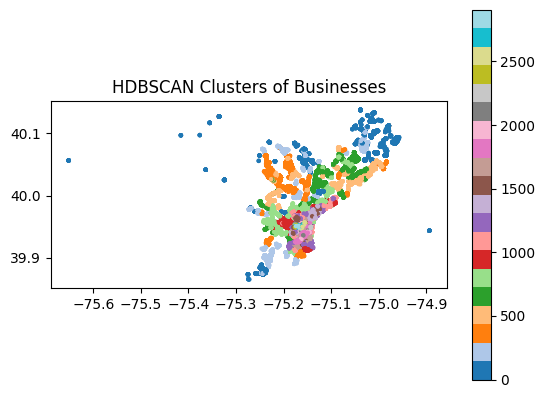

In [6]:
if 'latitude' not in df.columns or 'longitude' not in df.columns:
    raise KeyError("Missing 'latitude' or 'longitude' columns.")
coords = df[['latitude', 'longitude']].to_numpy()
coords_rad = np.radians(coords)

clusterer = hdbscan.HDBSCAN(min_cluster_size=10, metric='haversine')
df['hdbscan_cluster'] = clusterer.fit_predict(coords_rad)

valid_clusters = df[df['hdbscan_cluster'] != -1]
cluster_metrics = valid_clusters.groupby('hdbscan_cluster').agg(
    avg_sentiment=('sentiment_score', 'mean'),
    avg_subjectivity=('subjectivity_score', 'mean'),
    avg_stars=('stars_rev', 'mean'),
    business_count=('hdbscan_cluster', 'count')
).reset_index()
print("Cluster-Level Metrics:")
print(cluster_metrics)

cluster_topic_distribution = valid_clusters.groupby(['hdbscan_cluster', 'topic_label']).size().unstack(fill_value=0)
print("Cluster Topic Distribution:")
print(cluster_topic_distribution)

gdf_businesses = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.longitude, df.latitude), crs="EPSG:4326")
plt.figure(figsize=(10, 8))
gdf_businesses[gdf_businesses['hdbscan_cluster'] != -1].plot(column='hdbscan_cluster', cmap='tab20', legend=True, markersize=5)
plt.title("HDBSCAN Clusters of Businesses")
plt.savefig("clusters_plot.png")
# plt.show()

# Interactive Map

In [7]:
unique_clusters = sorted(df['hdbscan_cluster'].unique())
traces = []
colors = px.colors.qualitative.Plotly
color_map = {cluster: colors[i % len(colors)] for i, cluster in enumerate(unique_clusters)}

for cluster in unique_clusters:
    sub_df = df[df['hdbscan_cluster'] == cluster]
    trace = go.Scattermapbox(
        lat=sub_df['latitude'],
        lon=sub_df['longitude'],
        mode='markers',
        marker=go.scattermapbox.Marker(size=8, color=color_map[cluster]),
        name=f"Cluster {cluster}" if cluster != -1 else "Noise",
        text=sub_df['topic_label'],
        hovertemplate="<b>Cluster: " + str(cluster) + "</b><br>" +
                      "Topic: %{text}<br>" +
                      "Sentiment: %{customdata[0]:.2f}<br>" +
                      "Stars: %{customdata[1]}<extra></extra>",
        customdata=np.stack((sub_df['sentiment_score'], sub_df['stars_rev']), axis=-1)
    )
    traces.append(trace)

button_all = dict(args=[{"visible": [True] * len(traces)}],
                  label="All", method="update")
buttons = [button_all]
for i, cluster in enumerate(unique_clusters):
    visibility = [False] * len(traces)
    visibility[i] = True
    buttons.append(dict(args=[{"visible": visibility}],
                        label=f"Cluster {cluster}" if cluster != -1 else "Noise",
                        method="update"))

fig = go.Figure(data=traces)
fig.update_layout(
    updatemenus=[dict(active=0, buttons=buttons,
                      x=0.01, y=1.15, xanchor="left", yanchor="top",
                      direction="down", showactive=True)],
    mapbox=dict(
        style="carto-positron",
        zoom=11,
        center=dict(lat=df['latitude'].mean(), lon=df['longitude'].mean())
    ),
    margin={"r": 0, "t": 80, "l": 0, "b": 0},
    title="Interactive Map of Business Clusters in Philadelphia"
)

fig.write_html("interactive_business_clusters.html")
print("Interactive map saved as interactive_business_clusters.html")

# fig.show()

C:\Users\alche\AppData\Local\Temp\ipykernel_23644\555841795.py:8: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  trace = go.Scattermapbox(


Interactive map saved as interactive_business_clusters.html


# Statistical Analysis

In [8]:
postal_agg = df.groupby('postal_code').agg(
    avg_sentiment=('sentiment_score', 'mean'),
    avg_subjectivity=('subjectivity_score', 'mean'),
    avg_stars=('stars_rev', 'mean'),
    count=('postal_code', 'count')
).reset_index()
print("Postal Code Aggregation:")
print(postal_agg)

rho, pval = pearsonr(postal_agg['avg_sentiment'], postal_agg['avg_stars'])
print(f"Spearman correlation (sentiment vs. stars) by postal code: {rho:.2f} (p={pval:.3f})")

X = postal_agg[['avg_stars', 'count']]
X = sm.add_constant(X)
y = postal_agg['avg_sentiment']
model = sm.OLS(y, X).fit()
print(model.summary())
with open("regression_summary.txt", "w") as f:
    f.write(model.summary().as_text())
print("Regression summary saved to regression_summary.txt")

Postal Code Aggregation:
   postal_code  avg_sentiment  avg_subjectivity  avg_stars  count
0                    0.574850          0.409681   4.750000      4
1        08102       0.788600          0.632706   4.666667      9
2        18976       0.946000          0.668150   4.200000      5
3        19003       0.179600          0.285000   1.000000      1
4        19006       0.644164          0.537490   4.461538     39
..         ...            ...               ...        ...    ...
73       19341       0.897046          0.618593   4.923077     13
74       19401       0.654427          0.525387   4.091837     98
75       19428       0.497657          0.441316   4.428571      7
76       19446       0.978500          0.529931   5.000000      2
77       55101      -0.855500          0.471429   1.000000      1

[78 rows x 5 columns]
Spearman correlation (sentiment vs. stars) by postal code: 0.84 (p=0.000)
                            OLS Regression Results                            
Dep. Va